In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os
from pathlib import Path

# Paths
BASE = Path("C:/Users/nanig/OneDrive/Desktop/bluestock_mf_capstone")
PROCESSED = BASE / "data/processed"
CHARTS = BASE / "data/processed/charts"
CHARTS.mkdir(exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Load datasets
nav = pd.read_csv(PROCESSED / "clean_nav.csv")
transactions = pd.read_csv(PROCESSED / "clean_transactions.csv")
performance = pd.read_csv(PROCESSED / "clean_performance.csv")
fund_master = pd.read_csv(PROCESSED / "clean_fund_master.csv")
aum = pd.read_csv(PROCESSED / "clean_aum.csv")
sip = pd.read_csv(PROCESSED / "clean_sip.csv")
folio = pd.read_csv(PROCESSED / "clean_folio.csv")
portfolio = pd.read_csv(PROCESSED / "clean_portfolio.csv")

print("✅ All data loaded!")
print(f"NAV: {nav.shape}, Transactions: {transactions.shape}, Performance: {performance.shape}")

✅ All data loaded!
NAV: (46000, 3), Transactions: (32778, 13), Performance: (40, 19)


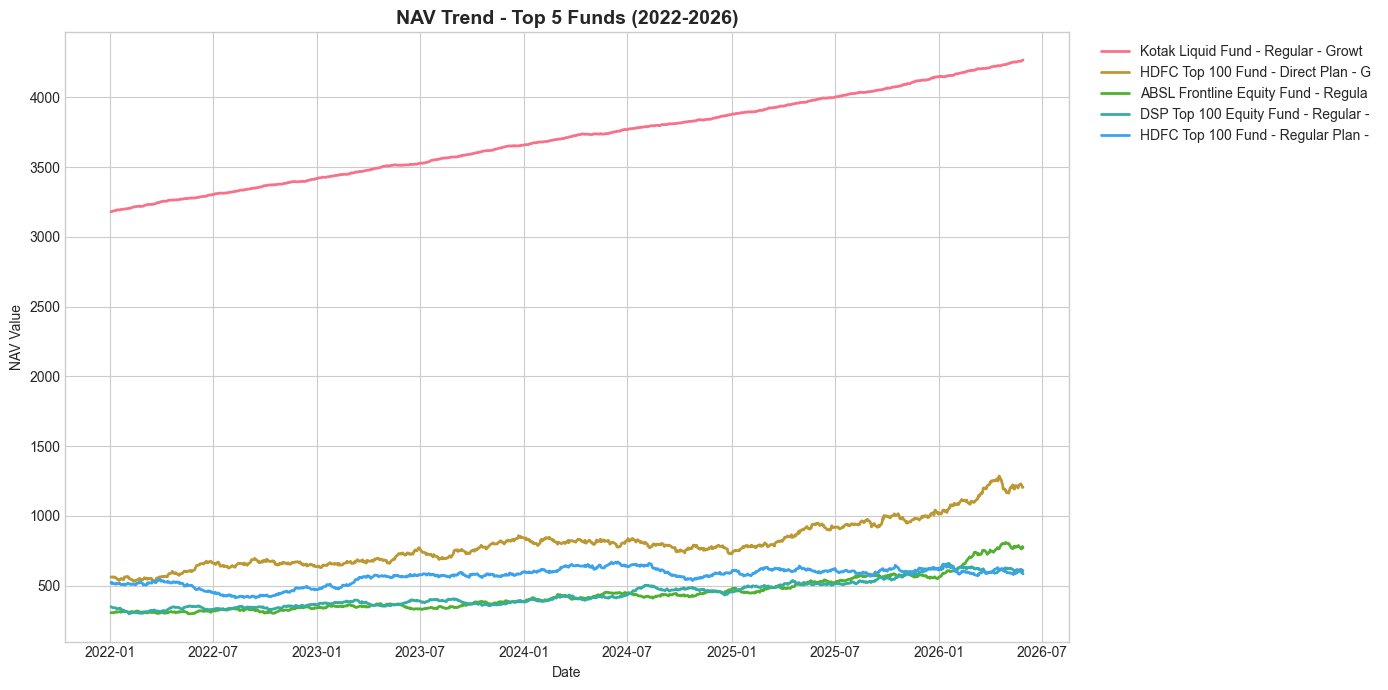

✅ Chart 1 saved!


In [4]:
# CHART 1: NAV Trend - Top 5 Funds
nav['date'] = pd.to_datetime(nav['date'])
nav = nav.sort_values(['amfi_code', 'date'])

# Get top 5 funds by last NAV value
top5 = nav.groupby('amfi_code')['nav'].last().sort_values(ascending=False).head(5).index

plt.figure(figsize=(14, 7))
for code in top5:
    fund_nav = nav[nav['amfi_code'] == code]
    name = fund_master[fund_master['amfi_code'] == code]['scheme_name'].values[0][:35]
    plt.plot(fund_nav['date'], fund_nav['nav'], label=name, linewidth=2)

plt.title('NAV Trend - Top 5 Funds (2022-2026)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('NAV Value')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(CHARTS / '01_nav_trend_top5.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 1 saved!")

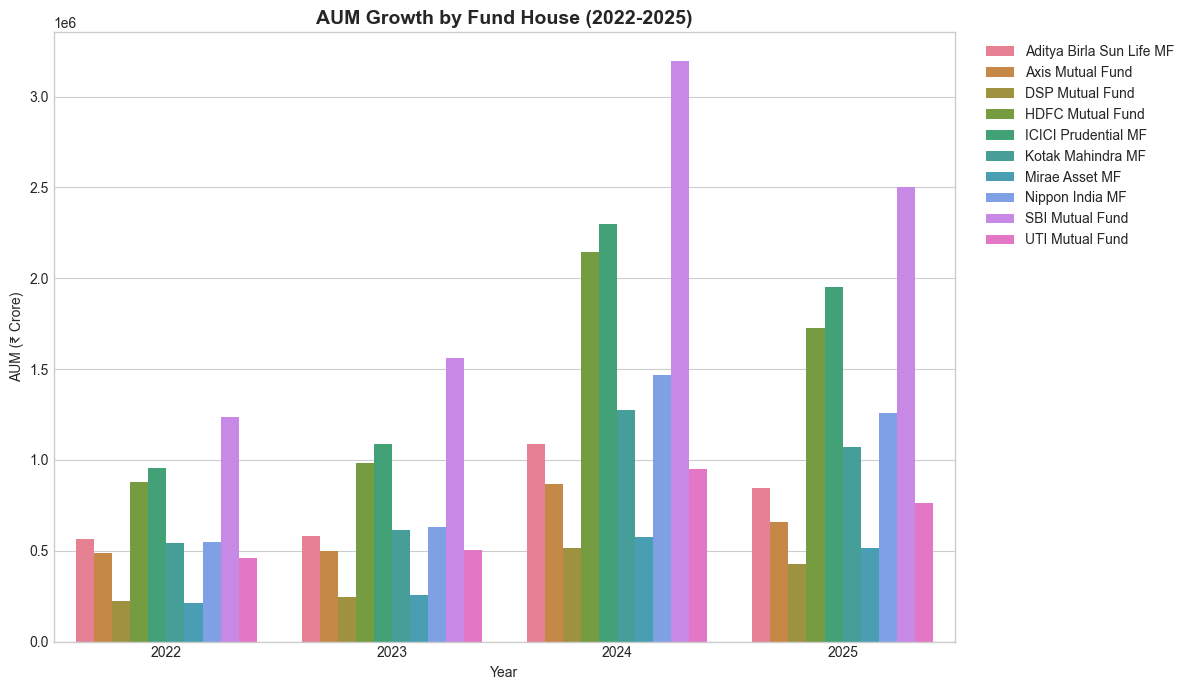

✅ Chart 2 saved!


In [5]:
# CHART 2: AUM Growth by Fund House
aum['date'] = pd.to_datetime(aum['date'])
aum['year'] = aum['date'].dt.year
aum['aum_crore'] = pd.to_numeric(aum['aum_crore'], errors='coerce')

aum_year = aum.groupby(['fund_house', 'year'])['aum_crore'].sum().reset_index()
aum_year = aum_year[aum_year['year'] >= 2022]

plt.figure(figsize=(12, 7))
sns.barplot(data=aum_year, x='year', y='aum_crore', hue='fund_house', errorbar=None)
plt.title('AUM Growth by Fund House (2022-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('AUM (₹ Crore)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(CHARTS / '02_aum_growth.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 2 saved!")

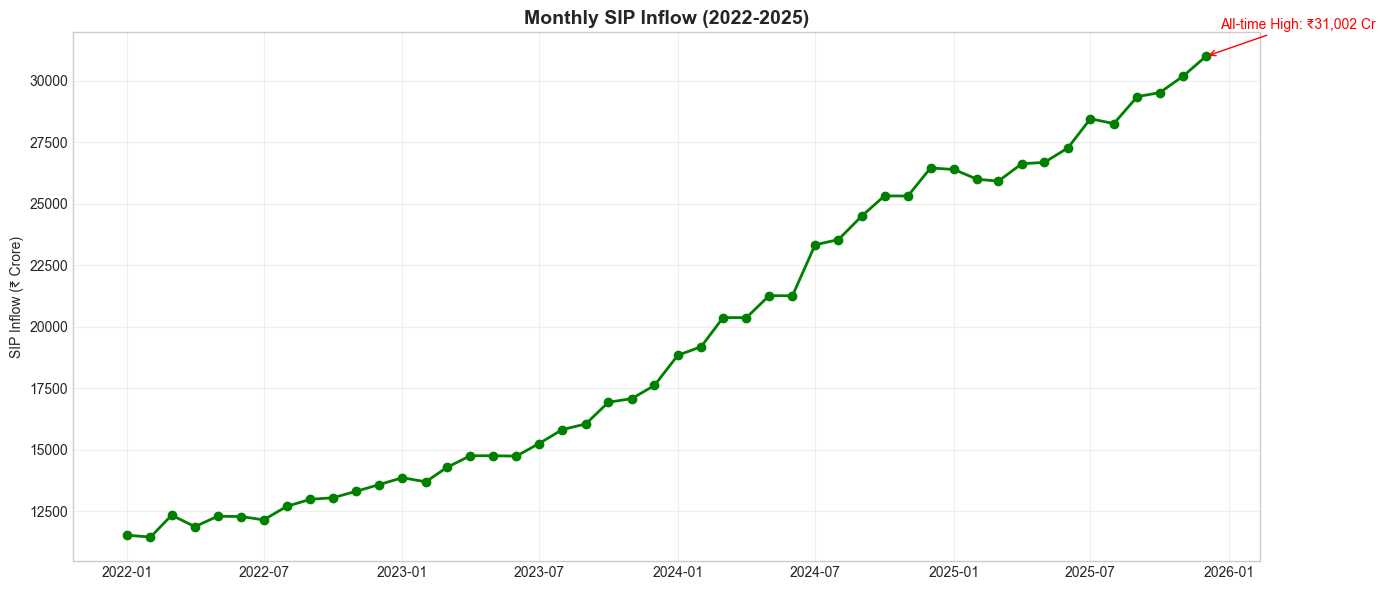

✅ Chart 3 saved!


In [6]:
# CHART 3: Monthly SIP Inflow
sip['month'] = pd.to_datetime(sip['month'])
sip = sip.sort_values('month')
sip['sip_inflow_crore'] = pd.to_numeric(sip['sip_inflow_crore'], errors='coerce')

plt.figure(figsize=(14, 6))
plt.plot(sip['month'], sip['sip_inflow_crore'], marker='o', linewidth=2, color='green')

# Annotate all-time high
max_idx = sip['sip_inflow_crore'].idxmax()
max_val = sip.loc[max_idx]
plt.annotate(f'All-time High: ₹{max_val["sip_inflow_crore"]:,.0f} Cr', 
            xy=(max_val['month'], max_val['sip_inflow_crore']),
            xytext=(10, 20), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='red'), fontsize=10, color='red')

plt.title('Monthly SIP Inflow (2022-2025)', fontsize=14, fontweight='bold')
plt.ylabel('SIP Inflow (₹ Crore)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(CHARTS / '03_sip_inflow.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 3 saved!")

Columns: ['month', 'category', 'net_inflow_crore']


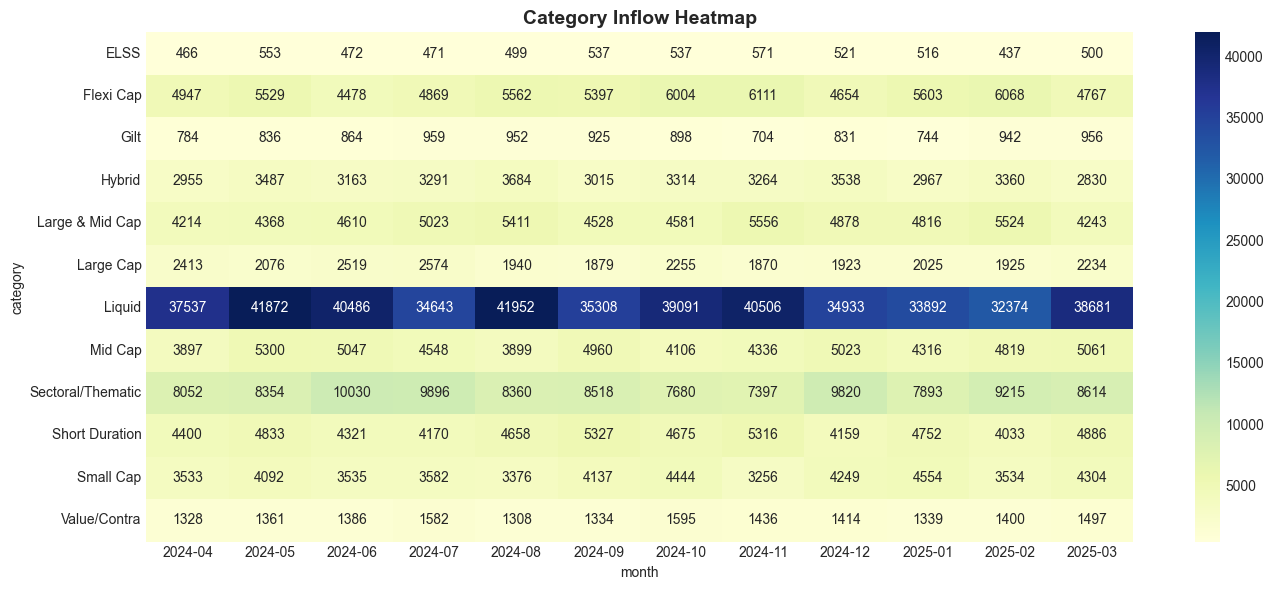

✅ Chart 4 saved!


In [7]:
# CHART 4: Category Inflow Heatmap
try:
    cat = pd.read_csv(PROCESSED / "clean_cat.csv")
    cat.columns = [c.strip().lower() for c in cat.columns]
    print("Columns:", cat.columns.tolist())
    
    cat['month'] = pd.to_datetime(cat['month'])
    cat['net_inflow_crore'] = pd.to_numeric(cat['net_inflow_crore'], errors='coerce')
    
    heatmap_data = cat.pivot_table(index='category', 
                                   columns=cat['month'].dt.strftime('%Y-%m'), 
                                   values='net_inflow_crore', aggfunc='sum')
    
    plt.figure(figsize=(14, 6))
    sns.heatmap(heatmap_data, cmap='YlGnBu', annot=True, fmt='.0f')
    plt.title('Category Inflow Heatmap', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(CHARTS / '04_category_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Chart 4 saved!")
except Exception as e:
    print(f"Error: {e}")

C:\Users\nanig\AppData\Local\Temp\ipykernel_24516\3393491574.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sip_data, x='age_group', y='amount_inr', ax=axes[1], palette='husl')


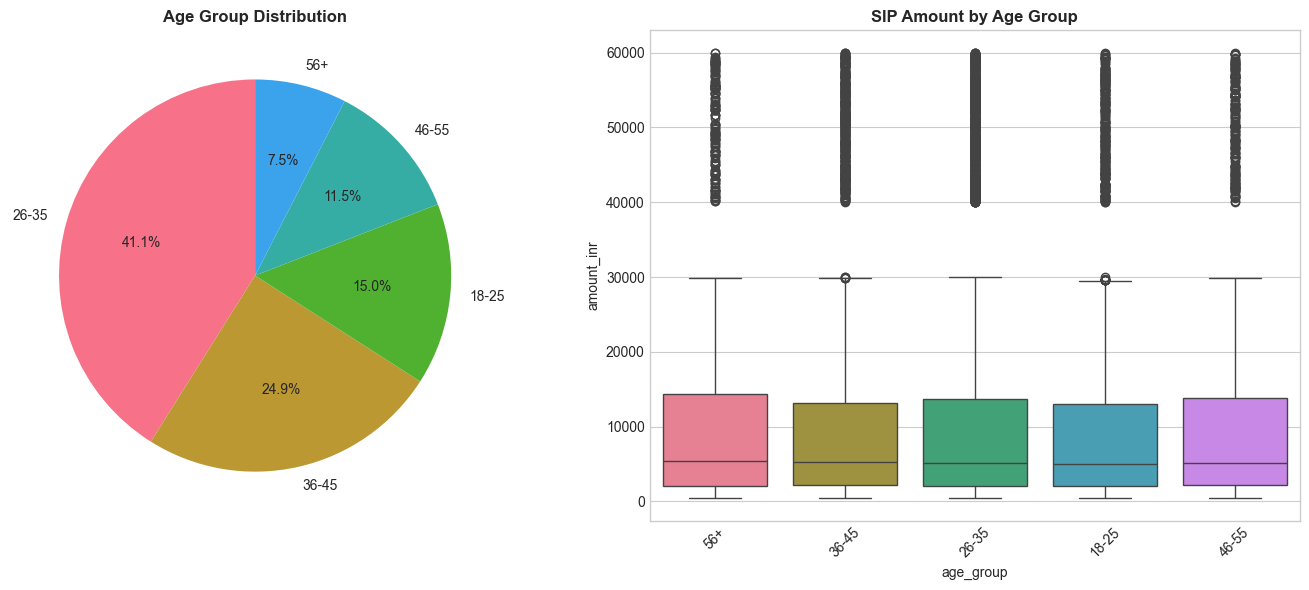

✅ Chart 5 saved!


In [8]:
# CHART 5: Investor Demographics - Age Group
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart
age_dist = transactions['age_group'].value_counts()
axes[0].pie(age_dist, labels=age_dist.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Age Group Distribution', fontsize=12, fontweight='bold')

# Box plot
transactions['amount_inr'] = pd.to_numeric(transactions['amount_inr'], errors='coerce')
sip_data = transactions[transactions['transaction_type'].str.lower() == 'sip']
sns.boxplot(data=sip_data, x='age_group', y='amount_inr', ax=axes[1], palette='husl')
axes[1].set_title('SIP Amount by Age Group', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(CHARTS / '05_demographics_age.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 5 saved!")

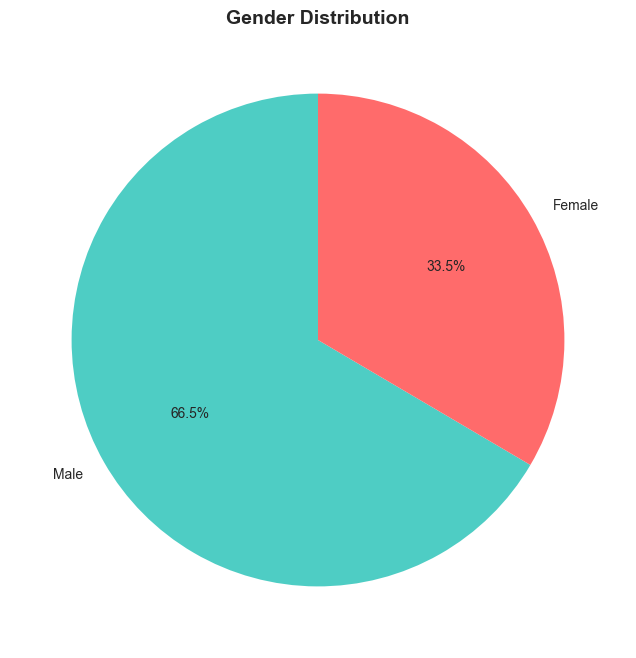

✅ Chart 6 saved!


In [9]:
# CHART 6: Gender Split
gender = transactions['gender'].value_counts()
plt.figure(figsize=(8, 8))
colors = ['#4ECDC4', '#FF6B6B']
plt.pie(gender, labels=gender.index, autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Gender Distribution', fontsize=14, fontweight='bold')
plt.savefig(CHARTS / '06_demographics_gender.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 6 saved!")

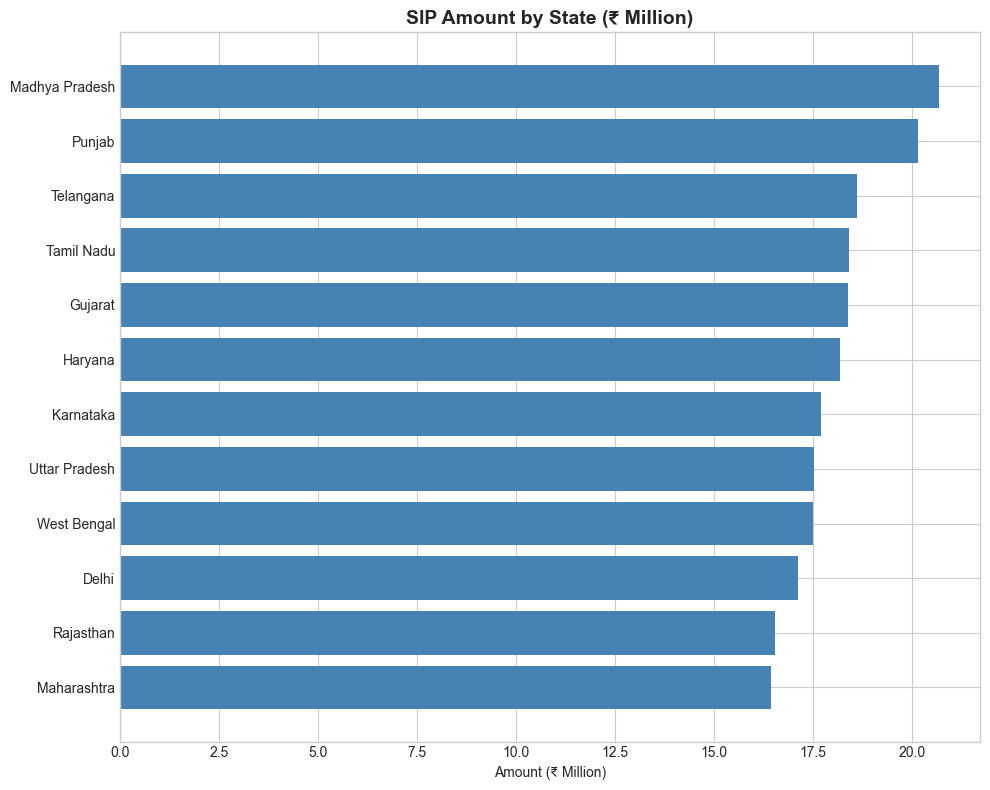

✅ Chart 7 saved!


In [10]:
# CHART 7: SIP by State
state_sip = transactions[transactions['transaction_type'].str.lower() == 'sip'].groupby('state')['amount_inr'].sum().reset_index()
state_sip = state_sip.sort_values('amount_inr', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(state_sip['state'], state_sip['amount_inr']/1e6, color='steelblue')
plt.title('SIP Amount by State (₹ Million)', fontsize=14, fontweight='bold')
plt.xlabel('Amount (₹ Million)')
plt.tight_layout()
plt.savefig(CHARTS / '07_state_sip.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 7 saved!")

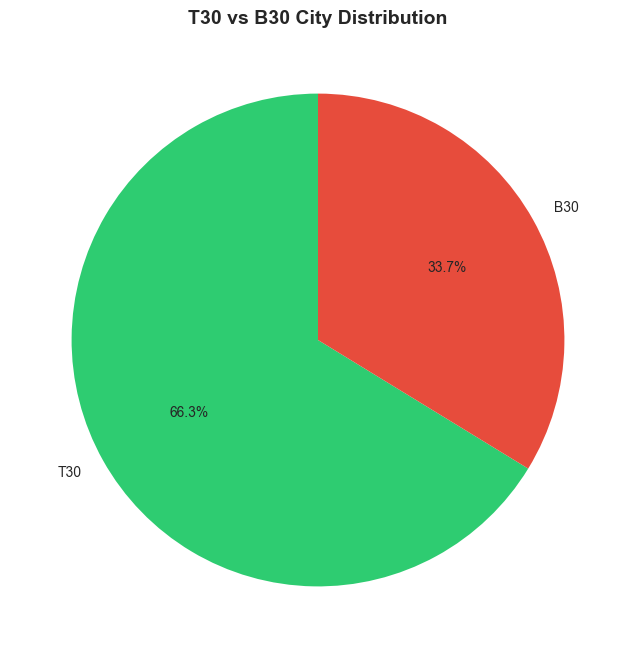

✅ Chart 8 saved!


In [11]:
# CHART 8: T30 vs B30
city_tier = transactions['city_tier'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(city_tier, labels=city_tier.index, autopct='%1.1f%%', startangle=90, 
        colors=['#2ECC71', '#E74C3C'])
plt.title('T30 vs B30 City Distribution', fontsize=14, fontweight='bold')
plt.savefig(CHARTS / '08_city_tier.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 8 saved!")

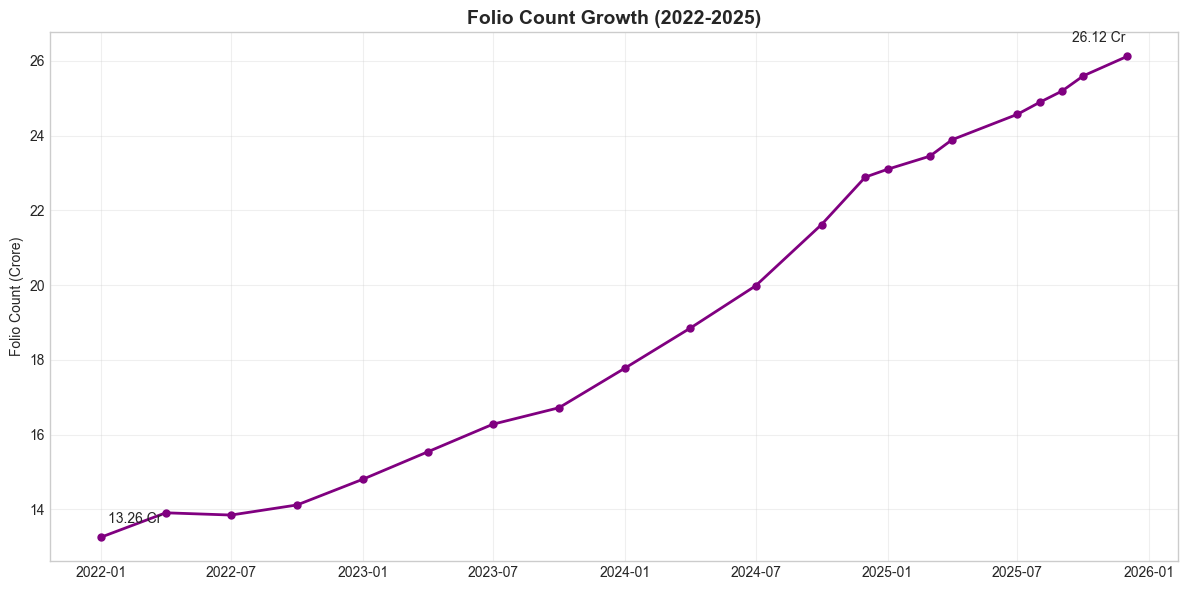

✅ Chart 9 saved!


In [14]:
# CHART 9: Folio Count Growth
folio['month'] = pd.to_datetime(folio['month'])
folio = folio.sort_values('month')

plt.figure(figsize=(12, 6))
plt.plot(folio['month'], folio['total_folios_crore'], marker='o', linewidth=2, markersize=5, color='purple')

# Annotate milestones
plt.annotate(f'{folio["total_folios_crore"].iloc[0]:.2f} Cr', 
            xy=(folio['month'].iloc[0], folio['total_folios_crore'].iloc[0]),
            xytext=(5, 10), textcoords='offset points', fontsize=10)
plt.annotate(f'{folio["total_folios_crore"].iloc[-1]:.2f} Cr', 
            xy=(folio['month'].iloc[-1], folio['total_folios_crore'].iloc[-1]),
            xytext=(-40, 10), textcoords='offset points', fontsize=10)

plt.title('Folio Count Growth (2022-2025)', fontsize=14, fontweight='bold')
plt.ylabel('Folio Count (Crore)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(CHARTS / '09_folio_growth.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 9 saved!")

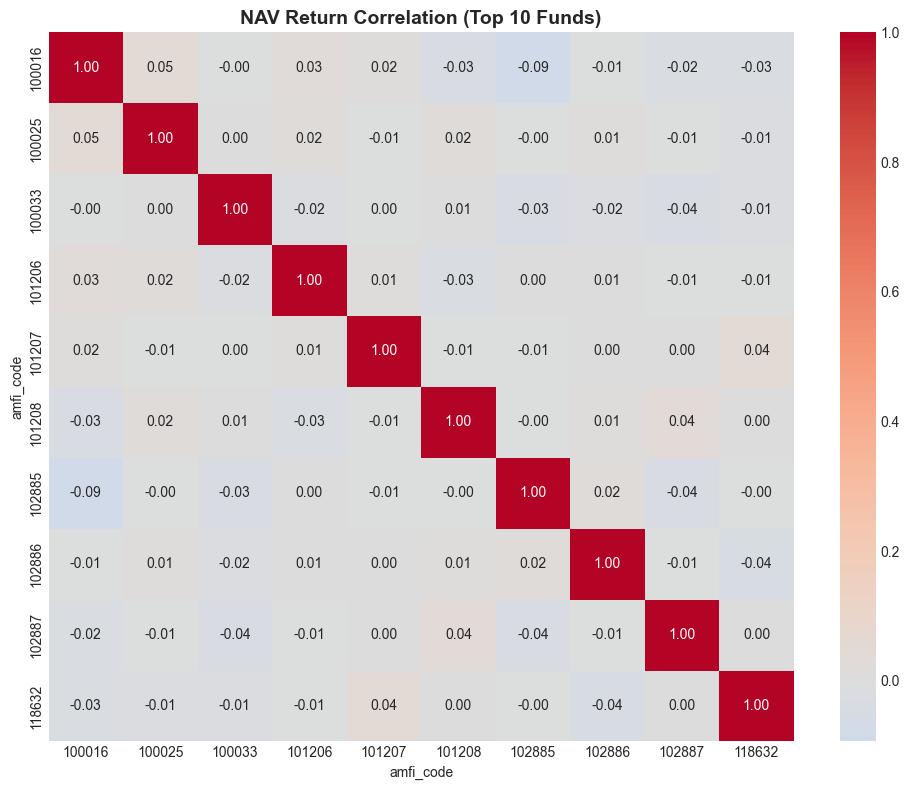

✅ Chart 10 saved!


In [15]:
# CHART 10: Correlation Matrix
top10_codes = nav.groupby('amfi_code')['nav'].count().sort_values(ascending=False).head(10).index
nav_pivot = nav[nav['amfi_code'].isin(top10_codes)].pivot_table(index='date', columns='amfi_code', values='nav')
returns = nav_pivot.pct_change().dropna()
corr = returns.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('NAV Return Correlation (Top 10 Funds)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(CHARTS / '10_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 10 saved!")

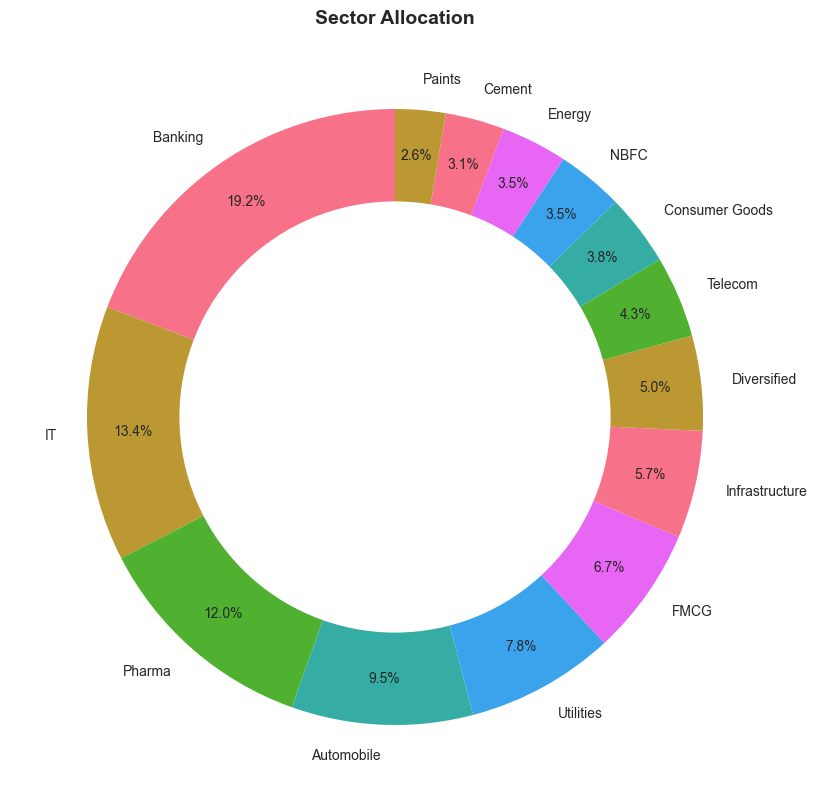

✅ Chart 11 saved!


In [16]:
# CHART 11: Sector Allocation Donut
sector = portfolio.groupby('sector')['weight_pct'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 10))
plt.pie(sector, labels=sector.index, autopct='%1.1f%%', startangle=90, pctdistance=0.85)
plt.gca().add_artist(plt.Circle((0,0), 0.70, fc='white'))
plt.title('Sector Allocation', fontsize=14, fontweight='bold')
plt.savefig(CHARTS / '11_sector_allocation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 11 saved!")

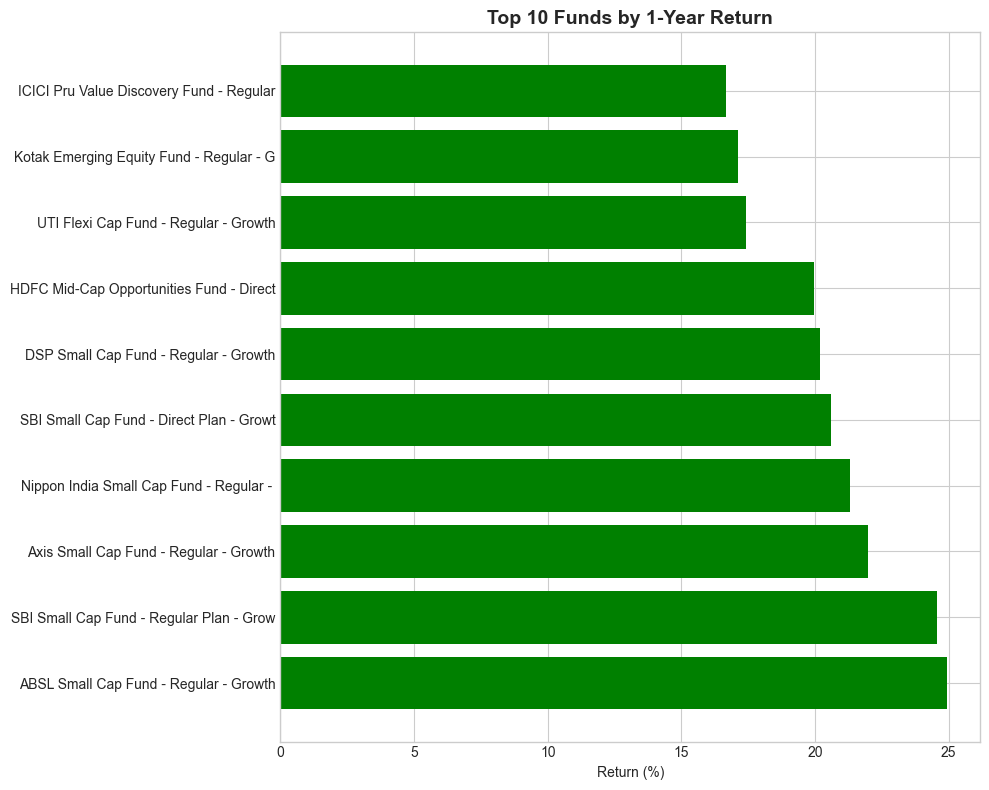

✅ Chart 12 saved!


In [17]:
# CHART 12: Top 10 Performers
top_perf = performance.nlargest(10, 'return_1yr_pct')[['scheme_name', 'return_1yr_pct']]
top_perf['scheme_name'] = top_perf['scheme_name'].str[:40]

plt.figure(figsize=(10, 8))
plt.barh(top_perf['scheme_name'], top_perf['return_1yr_pct'], color='green')
plt.title('Top 10 Funds by 1-Year Return', fontsize=14, fontweight='bold')
plt.xlabel('Return (%)')
plt.tight_layout()
plt.savefig(CHARTS / '12_top_performers.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 12 saved!")

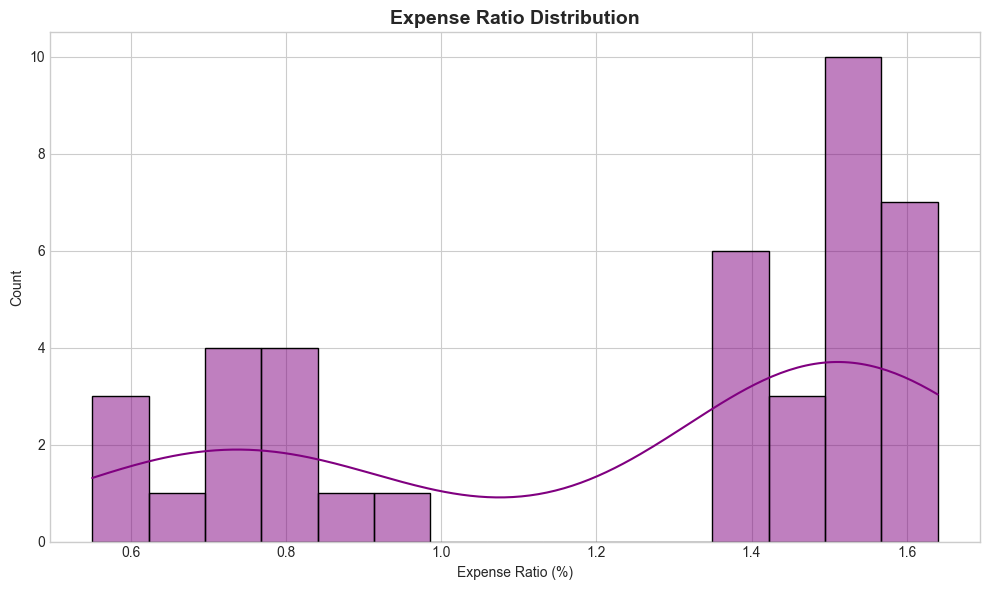

✅ Chart 13 saved!


In [18]:
# CHART 13: Expense Ratio Distribution
plt.figure(figsize=(10, 6))
sns.histplot(data=performance, x='expense_ratio_pct', bins=15, kde=True, color='purple')
plt.title('Expense Ratio Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Expense Ratio (%)')
plt.tight_layout()
plt.savefig(CHARTS / '13_expense_ratio.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 13 saved!")

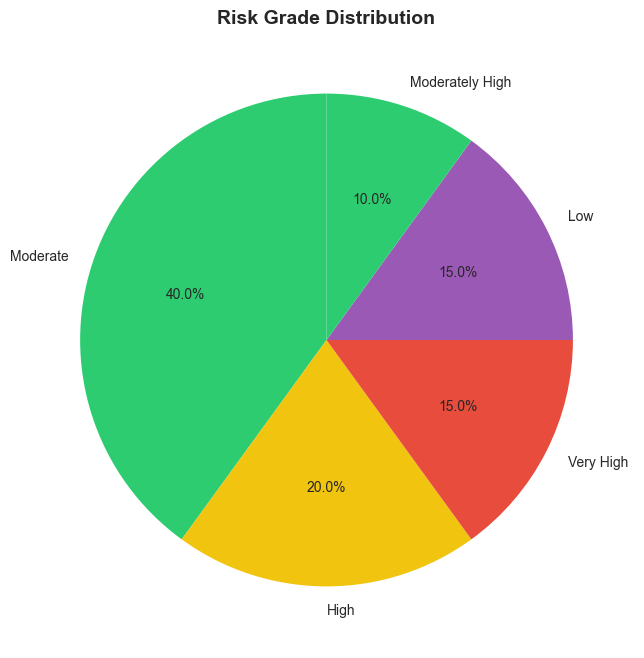

✅ Chart 14 saved!


In [19]:
# CHART 14: Risk Grade Distribution
risk = performance['risk_grade'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(risk, labels=risk.index, autopct='%1.1f%%', startangle=90, 
        colors=['#2ECC71', '#F1C40F', '#E74C3C', '#9B59B6'])
plt.title('Risk Grade Distribution', fontsize=14, fontweight='bold')
plt.savefig(CHARTS / '14_risk_grade.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 14 saved!")

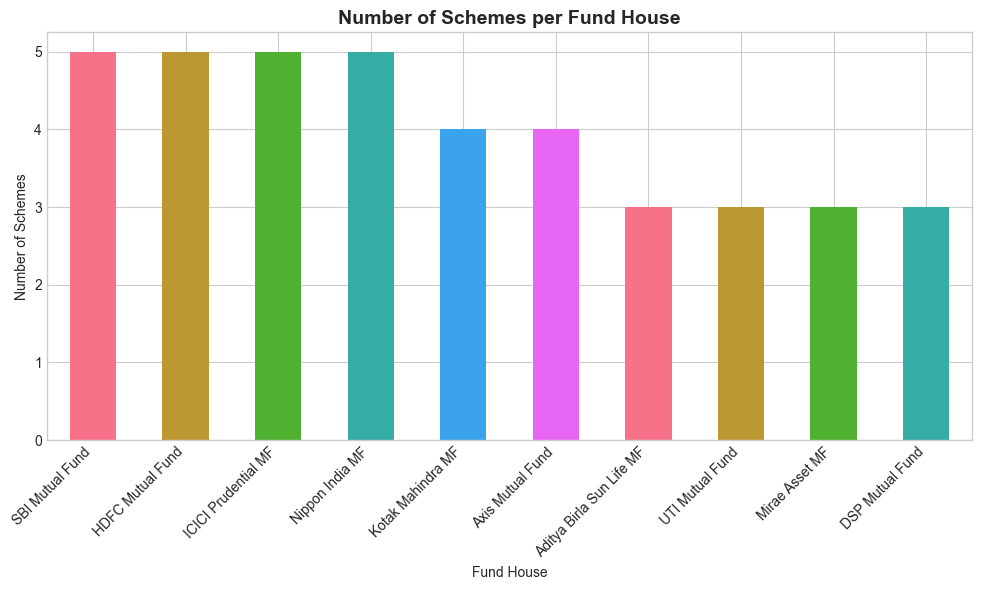

✅ Chart 15 saved!


In [20]:
# CHART 15: Schemes per Fund House
fh_count = fund_master['fund_house'].value_counts()
plt.figure(figsize=(10, 6))
fh_count.plot(kind='bar', color=sns.color_palette('husl'))
plt.title('Number of Schemes per Fund House', fontsize=14, fontweight='bold')
plt.xlabel('Fund House')
plt.ylabel('Number of Schemes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(CHARTS / '15_fund_house_count.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 15 saved!")

In [21]:
# Summary of all charts
import os
charts = list(CHARTS.glob('*.png'))
print("=" * 50)
print("✅ DAY 3 COMPLETE - ALL CHARTS SAVED!")
print("=" * 50)
print(f"\nTotal Charts: {len(charts)}")
for c in sorted(charts):
    print(f"  📊 {c.name}")

✅ DAY 3 COMPLETE - ALL CHARTS SAVED!

Total Charts: 15
  📊 01_nav_trend_top5.png
  📊 02_aum_growth.png
  📊 03_sip_inflow.png
  📊 04_category_heatmap.png
  📊 05_demographics_age.png
  📊 06_demographics_gender.png
  📊 07_state_sip.png
  📊 08_city_tier.png
  📊 09_folio_growth.png
  📊 10_correlation.png
  📊 11_sector_allocation.png
  📊 12_top_performers.png
  📊 13_expense_ratio.png
  📊 14_risk_grade.png
  📊 15_fund_house_count.png
